# Semantic Invariance (SI) and Semantically Orthogonal Artifact Projection (SOAP)

In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
import torch
import matplotlib.pyplot as plt

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


This notebook serves as a playground for testing out the SI score and SOAP. Start by loading a pretrained model. We have provided some example models in `get_models.py`, or you can load your own.

In [ ]:
# Get a pretrained model
from get_models import get_dense_backbone, get_patch_size
modelname = 'capi_large'
model = get_dense_backbone(modelname).to(device).eval()
patch_size = get_patch_size(modelname)

## How to calculate the Semantic Orthogonal Projector (SOaP)

Start by loading a dataset for estimating the covariance and calculating Semantic Invariance scores. This can for example be ImageNet, but the result is very similar with smaller datasets as well.

In [ ]:
# Standard transforms
import torchvision as tv
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
imgsize = 224
proc = tv.transforms.Compose([
        tv.transforms.RandomResizedCrop((imgsize, imgsize), (1., 1.)),
        tv.transforms.ToTensor(),
        tv.transforms.Normalize(mean, std),
    ])

# Load ImageNet or another dataset to estimate the embedding covariance of the model
data = ...
batch_size = 512
dataloader = torch.utils.data.DataLoader(data, batch_size, num_workers=4, prefetch_factor=2, pin_memory=True)

The SOaP projection only needs to be calculated once. The results are saved in a `weights` folder, unless otherwise specified. If you want the projection to be calculated from scratch, you have to delete the files from the `weights` folder.

In [ ]:
from fit_projector import fit_WCE, fit_projector

# Estimate the covariance
cov_data = fit_WCE(model, dataloader, modelname, device)

In [ ]:
from soap.synth import SynthesizedDataSet

# Synthetic dataset to match the real dataset
dataset_length = len(data)
dataloader_synth = SynthesizedDataSet(size=imgsize, channels=3, 
    batch_size=dataloader.batch_size, length=dataset_length)

# Fit the projector
projector = fit_projector(
    model, cov_data, dataloader, dataloader_synth,
    modelname, imgsize, patch_size, device).to(device)

## Salient segmentation 

In [ ]:
from salient.bilateral import *
from salient.ncut import *
from salient.metrics import *
from salient.util import *
from soap import SOAP, WelfordChanEstimator

In [ ]:
# Load a pretrained model and projector
modelname = 'dinov2_base'
features = 'out'

model = get_dense_backbone(modelname).to(device).eval()
patch_size = get_patch_size(modelname)

# projector = SOAP.deserialize(f'weights/{modelname}_projector.pth').to(device)
projector = SOAP.from_modelname(modelname, 'weights',).to(device)
cov_data = WelfordChanEstimator.deserialize(f'weights/{modelname}_cov.pth').to(device)

In [ ]:
# Load ECSSD dataset
ecssd = ...

# Principal component salient guide
pca_guide_dim = -2 # -2 for DINOv2, -1 for CAPI
flip_guide = True

from functools import partial
from main_salient import get_guide_response
W, b = cov_data.get_truncated_weights_and_biases_at_indices([pca_guide_dim])
get_guide = partial(get_guide_response, W=W.mT, b=b, flip=flip_guide)

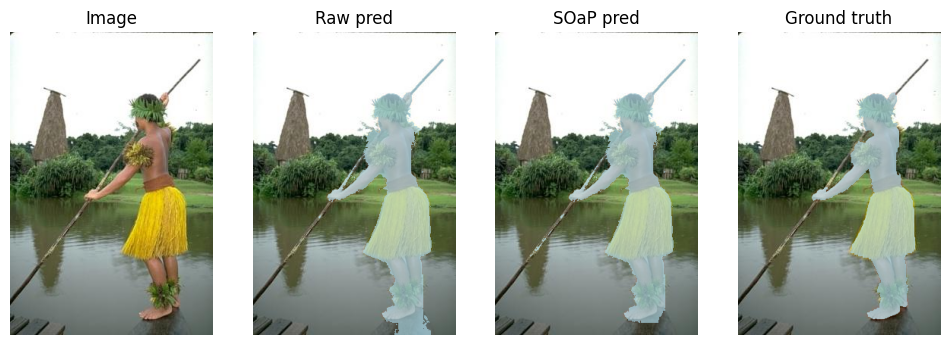

In [ ]:
# Choose image
i = 0
img, seg = ecssd[i]

# Convert input image to tensor
I_resize, w, h, feat_w, feat_h = resize_pil(img, patch_size)
trans = tv.transforms.Compose([
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.485, 0.456, 0.406),
                            (0.229, 0.224, 0.225)),])
tensor = trans(I_resize).unsqueeze(0)

# Get patch features from model
feat = model(tensor.to(device), vit_feat=features)[0]

# Get guide from pca
if pca_guide_dim is not None:
    guide = get_guide(feat).cpu().numpy()
else:
    guide = None

# Apply SOaP
corr_feat = projector(feat)

# TokenCut on raw feats
seed, bipartition, eigvec = ncut(
    feat.mT, dims=[feat_h, feat_w], 
    scales=[patch_size, patch_size], init_image_size=[h,w], 
    guide=None, foregound_selection='vmax', tau=0.3)

# Bilateral solver for edge refinement
output_solver, binary_solver = bilateral_solver_output(
    img, bipartition, 
    sigma_spatial = 16, 
    sigma_luma = 16, 
    sigma_chroma = 8
)
pred = output_solver

# TokenCut on corrected feats
seed, bipartition, eigvec = ncut(
    corr_feat.mT, dims=[feat_h, feat_w], 
    scales=[patch_size, patch_size], init_image_size=[h,w], 
    guide=guide, foregound_selection='pca', tau=0.3)

# Bilateral solver for edge refinement
output_solver, binary_solver = bilateral_solver_output(
    img, bipartition, 
    sigma_spatial = 16, 
    sigma_luma = 16, 
    sigma_chroma = 8
)
soap_pred = output_solver

# Visualize
org_img = np.array(img)
pred_img = mask_color_compose(org_img, pred)
soap_pred_img = mask_color_compose(org_img, soap_pred)
gt = mask_color_compose(org_img, seg)

imgs = [org_img, pred_img, soap_pred_img, gt]
labels = ['Image', 'Raw pred', 'SOaP pred', 'Ground truth']
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for ax, im, lab in zip(axes, imgs, labels):
    ax.imshow(im)
    ax.axis("off")
    ax.set_title(lab)
plt.show()